<a href="https://colab.research.google.com/github/mofidjoyoneiny-droid/Employie_a/blob/main/Malaria_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"joyoneiny","key":"450e0235829e47e207dc01340863c6b7"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!pip install kaggle

In [6]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:38<00:00, 18.6MB/s]



In [7]:
!unzip cell-images-for-detecting-malaria.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_118.png  
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_126.png  
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_134.png  
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_141.png  
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_168.png  
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_175.png  
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_183.png  
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_221.png  
  inflating: /content/cell_images/cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_222.png  
  inflating: /content/cell_imag

In [8]:
!ls /content/cell_images

cell_images  Parasitized  Uninfected


In [9]:
import os

data_dir = "/content/cell_images/cell_images"

In [10]:
os.listdir(data_dir)

['Uninfected', 'Parasitized']

In [12]:
for folder in os.listdir(data_dir):
    path = os.path.join(data_dir, folder)
    print(folder, ":", len(os.listdir(path)))

Uninfected : 13780
Parasitized : 13780


In [13]:
from PIL import Image
import random

class_name = random.choice(os.listdir(data_dir))
img_name = random.choice(os.listdir(os.path.join(data_dir, class_name)))

img_path = os.path.join(data_dir, class_name, img_name)

img = Image.open(img_path)

print("Class:", class_name)
print("Image size:", img.size)
print("Image mode:", img.mode)

Class: Uninfected
Image size: (106, 139)
Image mode: RGB


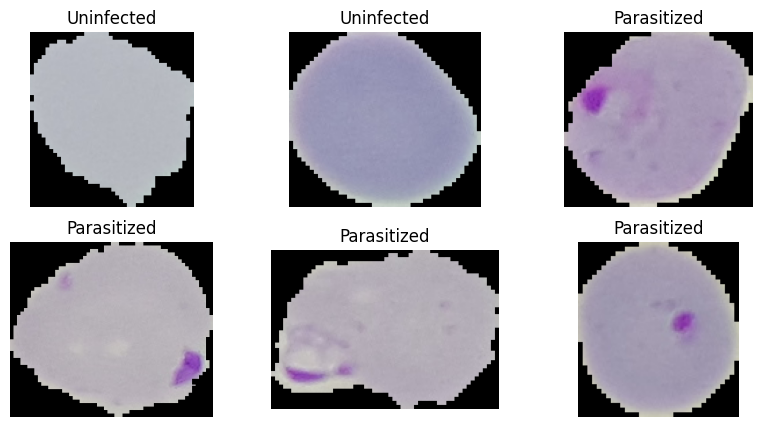

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):
    class_name = random.choice(os.listdir(data_dir))
    img_name = random.choice(os.listdir(os.path.join(data_dir,class_name)))

    img = Image.open(os.path.join(data_dir,class_name,img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import matplotlib.pyplot as plt

In [16]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [17]:
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 22048 images belonging to 2 classes.


In [18]:
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 5510 images belonging to 2 classes.


In [19]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 137s 190ms/step - accuracy: 0.8135 - loss: 0.3967 - val_accuracy: 0.9323 - val_loss: 0.1913
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 129s 188ms/step - accuracy: 0.9458 - loss: 0.1779 - val_accuracy: 0.9370 - val_loss: 0.1955
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 130s 189ms/step - accuracy: 0.9519 - loss: 0.1591 - val_accuracy: 0.9423 - val_loss: 0.1910
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 129s 188ms/step - accuracy: 0.9550 - loss: 0.1470 - val_accuracy: 0.9448 - val_loss: 0.1673
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 129s 187ms/step - accuracy: 0.9564 - loss: 0.1431 - val_accuracy: 0.9396 - val_loss: 0.1632
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 129s 187ms/step - accuracy: 0.9562 - loss: 0.1428 - val_accuracy: 0.9483 - val_loss: 0.1534
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 130s 189ms/step - accuracy: 0.9568 - loss: 0.1356 - val_accuracy: 0.9456 - val_loss: 0.1650
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 130s 188ms/step - accuracy: 0.9585 -

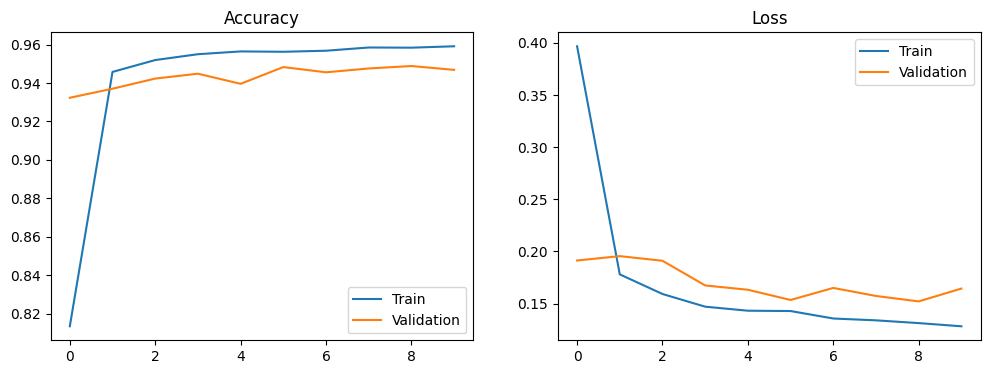

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

In [25]:
test_data = test_datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 4132 images belonging to 2 classes.


In [26]:
import numpy as np

predictions = model.predict(test_data)

# تحويل الاحتمالات إلى 0 أو 1
y_pred = (predictions > 0.5).astype(int)

# القيم الحقيقية
y_true = test_data.classes

130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step


In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Parasitized','Uninfected']
))

              precision    recall  f1-score   support

 Parasitized       0.98      0.91      0.94      2066
  Uninfected       0.92      0.98      0.95      2066

    accuracy                           0.94      4132
   macro avg       0.95      0.94      0.94      4132
weighted avg       0.95      0.94      0.94      4132



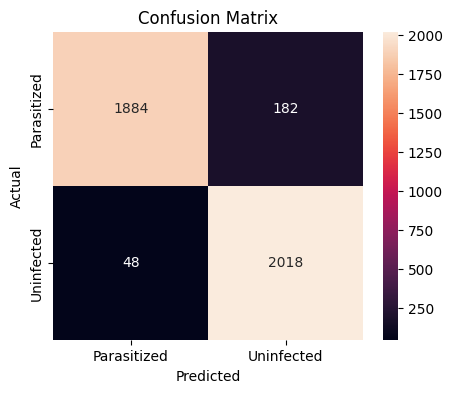

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Parasitized','Uninfected'],
    yticklabels=['Parasitized','Uninfected']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()